## KL 散度

KL 散度（Kullback-Leibler Divergence），也称为**相对熵**，主要用于衡量两个概率分布之间的差异。




### 1\. KL 散度的数学公式

假设有两个概率分布 $P$ 和 $Q$。通常情况下，$P$ 代表**真实分布**（或目标分布），$Q$ 代表**模型预测的分布**（或近似分布）。

对于离散概率分布，KL 散度的定义为：

$$
D_{KL}(P || Q) = \sum_{x} P(x) \log \left( \frac{P(x)}{Q(x)} \right)
$$

这个公式也可以展开写成：

$$
D_{KL}(P || Q) = \sum_{x} P(x) \log P(x) - \sum_{x} P(x) \log Q(x)
$$

**关键特性：**

  * **非对称性：** $D_{KL}(P || Q) \neq D_{KL}(Q || P)$。因此它不是严格意义上的“距离”。
  * **非负性：** $D_{KL}(P || Q) \geq 0$。只有当 $P$ 和 $Q$ 完全一致时，其值为 0。



### 2\. PyTorch 实现

在 PyTorch 中，可以使用 `torch.nn.functional.kl_div` 或 `torch.nn.KLDivLoss`。

> **⚠️ 重要注意事项：**
> PyTorch 的 `kl_div` 函数有一个常见的“坑”：它要求**输入（Input/Q）必须是 Log Probabilities（对数概率）**，而**目标（Target/P）通常是普通 Probabilities（概率）**。


In [1]:
import torch
import torch.nn.functional as F

# 1. 模拟数据
# 假设我们有 3 个类别，P 是真实分布，Q 是预测分布
# 真实分布 P (Target)：必须是概率分布 (sum=1)
P = torch.tensor([0.1, 0.4, 0.5])

# 预测的 Logits (未归一化的原始输出)
logits_Q = torch.tensor([0.2, 0.1, 0.9])

# ---------------------------------------------
# 2. 官方 API 实现 (推荐)
# ---------------------------------------------

# 关键步骤：对预测值 Q 进行 LogSoftmax 处理
log_Q = F.log_softmax(logits_Q, dim=0)

# 计算 KL 散度
# ⚠️ 注意：这里 P 的 shape 是 (3,)，PyTorch 把第一个维度当作 batch_size
# reduction='batchmean' 会除以 3，所以结果是 0.1124 / 3 = 0.0375
# 如果要和手动计算对比，应该用 reduction='sum'
kl_loss = F.kl_div(log_Q, P, reduction='batchmean')

print(f"PyTorch API 计算结果 (batchmean): {kl_loss.item():.4f}")
print(f"PyTorch API 计算结果 (sum):       {F.kl_div(log_Q, P, reduction='sum').item():.4f}")

# ---------------------------------------------
# 3. 手动实现 (用于理解公式)
# 公式: sum( P * (log(P) - log(Q)) )
# ---------------------------------------------

# 确保 Q 也是概率形式以便手动计算
Q = F.softmax(logits_Q, dim=0)

# 手动计算
# 注意：为了数值稳定性，通常直接用 P * (log P - log_Q_from_softmax)
manual_kl = torch.sum(P * (torch.log(P) - torch.log(Q)))

print(f"手动公式计算结果:    {manual_kl.item():.4f}")


PyTorch API 计算结果 (batchmean): 0.0375
PyTorch API 计算结果 (sum):       0.1124
手动公式计算结果:    0.1124


### 3\. 手动实现 KL 散度计算

要自己写一个跟 PyTorch 官方 F.kl_div 完全等效的实现，必须处理好以下两个核心细节，否则结果会对不上或出现 NaN：数值稳定性 ($0 \log 0$ 问题)：当真实分布 $P(x)=0$ 时，数学上极限为 0，但计算机直接算会得到 NaN。Reduction 模式 (batchmean vs mean)：这是 PyTorch 特有的定义，mean 是除以所有元素个数，而 batchmean 是除以 Batch Size（这才是数学上正确的平均 KL 散度）。


In [2]:
import torch
import torch.nn.functional as F


def my_kl_div(input_log_q, target_p, reduction="batchmean"):
    """
    手动实现等效于 torch.nn.functional.kl_div 的函数

    Args:
        input_log_q: 模型的预测输出，必须已经是 Log Softmax 后的结果 (log Q)
        target_p: 真实标签分布，通常是概率值 (P)
        reduction: 'none' | 'mean' | 'sum' | 'batchmean'
    """

    # 1. 计算 P * log(P) (熵的负数部分)
    # 细节：如果 P 中有 0，log(0) 是 -inf，0 * -inf 会变成 NaN。
    # 我们利用掩码 (mask) 仅对 P > 0 的部分计算，P=0 的部分设为 0。
    # -------------------------------------------------------------------
    # 创建一个全零张量，形状与 target 一致
    term_p_log_p = torch.zeros_like(target_p)

    # 找到 P > 0 的索引
    mask = target_p > 0

    # 仅在 P > 0 的位置计算 P * log(P)
    term_p_log_p[mask] = target_p[mask] * torch.log(target_p[mask])

    # 2. 计算 P * log(Q) (交叉熵的负数部分)
    # input_log_q 已经是 log(Q) 了，直接乘
    # -------------------------------------------------------------------
    term_p_log_q = target_p * input_log_q

    # 3. 逐元素计算 KL: P * log(P) - P * log(Q)
    # -------------------------------------------------------------------
    pointwise_kl = term_p_log_p - term_p_log_q

    # 4. 处理 Reduction (归约方式)
    # -------------------------------------------------------------------
    if reduction == "none":
        return pointwise_kl

    elif reduction == "sum":
        return torch.sum(pointwise_kl)

    elif reduction == "mean":
        # ⚠️ 注意：PyTorch 的 'mean' 是除以 "Tensor 中所有元素的总数"
        # 这在数学意义上通常是不对的（因为它把类别维度的求和也变成了平均），
        # 但官方实现就是这样。
        return torch.mean(pointwise_kl)

    elif reduction == "batchmean":
        # ✅ 这才是标准的 KL 散度平均。
        # 逻辑：先在非 Batch 维度求和 (sum over classes)，再除以 Batch Size。
        # PyTorch 官方实现实际上是：sum(all) / batch_size
        batch_size = input_log_q.size(0)
        return torch.sum(pointwise_kl) / batch_size

    else:
        raise ValueError(f"{reduction} is not a valid reduction method.")


In [3]:
# ==========================================
# 验证代码：对比官方实现与手动实现
# ==========================================

# 1. 准备数据 (Batch Size = 2, Classes = 3)
# 预测值 (Logits -> LogSoftmax)
logits = torch.tensor([[0.5, 0.2, 0.3], [0.1, 0.8, 0.1]], requires_grad=True)
input_log_q = F.log_softmax(logits, dim=1)

# 真实分布 (概率和为 1)，特意设置一个 0 来测试数值稳定性
target_p = torch.tensor([[0.1, 0.9, 0.0], [0.2, 0.5, 0.3]])

# 2. 对比 'batchmean' (最常用)
loss_official = F.kl_div(input_log_q, target_p, reduction="batchmean")
loss_custom = my_kl_div(input_log_q, target_p, reduction="batchmean")

print(f"--- 模式: batchmean ---")
print(f"官方结果: {loss_official.item():.6f}")
print(f"手动结果: {loss_custom.item():.6f}")
print(f"是否一致: {torch.isclose(loss_official, loss_custom)}")

# 3. 对比 'mean' (数学上不准确，但 API 存在)
loss_official_mean = F.kl_div(input_log_q, target_p, reduction="mean")
loss_custom_mean = my_kl_div(input_log_q, target_p, reduction="mean")

print(f"\n--- 模式: mean ---")
print(f"官方结果: {loss_official_mean.item():.6f}")
print(f"手动结果: {loss_custom_mean.item():.6f}")


--- 模式: batchmean ---
官方结果: 0.447411
手动结果: 0.447411
是否一致: True

--- 模式: mean ---
官方结果: 0.149137
手动结果: 0.149137


/var/folders/wd/ph815spj4c5cy3t17sqy9b8c0000gn/T/ipykernel_3551/3334206831.py:23: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  loss_official_mean = F.kl_div(input_log_q, target_p, reduction="mean")


#### 3.1\. 为什么官方 API 这么“别扭”？

你可能注意到了，官方 `kl_div` 要求的输入不对称：

  * **Input**: Log Probabilities (Log Space)
  * **Target**: Probabilities (Linear Space)

**原因：** 这样做是为了**数值稳定性**。如果让用户传 $Q$ 进来，函数内部再算 `log(Q)`，当 $Q$ 接近 0 时梯度会爆炸。通过强制用户传入 `log_softmax` 的结果，PyTorch 利用了 LogSoftmax 内部的 Log-Sum-Exp 技巧，保证了梯度的平滑和数值的稳定。

#### 3.2\. `batchmean` 到底做了什么？

这是很多人的盲区。

  * 假设 Input Shape 是 `(N, C)`。
  * **数学期望：** $Loss = \frac{1}{N} \sum_{i=1}^N \left( \sum_{j=1}^C P_{ij} \log \frac{P_{ij}}{Q_{ij}} \right)$。即：内部求和（算单个样本的 KL），外部求平均（算 Batch 的平均）。
  * **reduction='mean'**：PyTorch 会做 $\frac{1}{N \times C} \sum \sum ...$。它把类别数 $C$ 也除进去了，导致 Loss 值比真实值小了 $C$ 倍。
  * **reduction='batchmean'**：PyTorch 会做 $\frac{1}{N} \sum \sum ...$。这才是符合数学定义的做法。

#### 3.3\. 掩码 (Masking) 的重要性

在代码中 `mask = target_p > 0`这一步至关重要。
如果不加这一步，直接计算 `target_p * torch.log(target_p)`：
当 `target_p` 中某一项为 `0.0` 时，`torch.log(0.0)` 得到 `-inf`，然后 `0.0 * -inf` 得到 `NaN`。整个训练 Loss 瞬间变成 `NaN`。



### 4\. 在机器学习中的用途

KL 散度在深度学习中非常核心，以下是三个主要应用场景：

#### 4.1\. 变分自编码器 (VAEs)

这是 KL 散度最著名的应用之一。

  * **作用：** VAE 的损失函数包含两部分：重构损失（Reconstruction Loss）和 KL 散度正则项。
  * **原理：** 我们希望编码器（Encoder）生成的潜在向量分布（Latent distribution）尽可能接近标准正态分布 $N(0, 1)$。KL 散度在这里作为一种“惩罚项”，防止潜在空间过拟合或过于离散。

#### 4.2\. 知识蒸馏 (Knowledge Distillation)

  * **作用：** 将一个大模型（Teacher）的能力迁移到一个小模型（Student）。
  * **原理：** 训练 Student 模型时，不仅要求它的输出匹配真实标签（Hard Label），还要求它的输出概率分布 $Q$ 去逼近 Teacher 模型的输出概率分布 $P$（Soft Label）。KL 散度用来衡量这两个分布的差异。

#### 4.3\. 强化学习 (Reinforcement Learning)

  * **作用：** 保证策略更新的稳定性。
  * **原理：** 在 PPO (Proximal Policy Optimization) 或 TRPO (Trust Region Policy Optimization) 等算法中，我们希望新的策略（Policy）不要偏离旧策略太远。通过限制新旧策略分布之间的 KL 散度，可以防止模型在更新时“步子迈得太大”导致性能崩塌。

#### 4.4\. 与交叉熵 (Cross Entropy) 的关系

你可能常用交叉熵损失来做分类。其实：

$$
\text{CrossEntropy}(P, Q) = H(P) + D_{KL}(P || Q)
$$

  * 其中 $H(P)$ 是真实标签的熵。在监督学习中，真实标签 $P$ 通常是固定的（one-hot 编码），这意味着 $H(P)$ 是常数。
  * 因此，**最小化交叉熵损失等价于最小化 KL 散度**。


### 5. 可视化理解

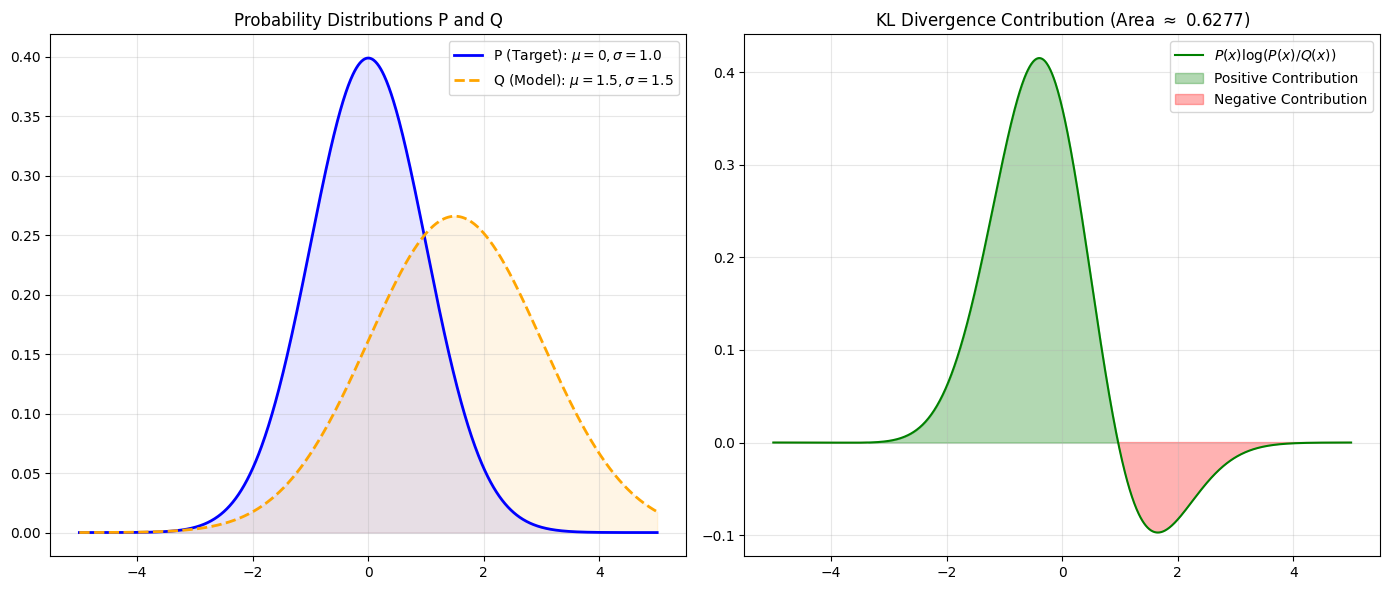

In [ ]:
import numpy as np
import torch

import matplotlib.pyplot as plt

# Set up data for visualization
x = np.linspace(-5, 5, 1000)


def gaussian(x, mu, sigma):
    return (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


# Define two distributions P and Q
# P: Target distribution (e.g., standard normal)
mu_p, sigma_p = 0, 1.0
P_dist = gaussian(x, mu_p, sigma_p)

# Q: Approximating distribution (shifted and wider)
mu_q, sigma_q = 1.5, 1.5
Q_dist = gaussian(x, mu_q, sigma_q)

# Calculate KL Divergence terms pointwise for visualization
# KL(P||Q) = sum( P * log(P/Q) )
# We use a small epsilon to avoid division by zero or log(0)
eps = 1e-10
kl_pq_pointwise = P_dist * np.log((P_dist + eps) / (Q_dist + eps))
kl_qp_pointwise = Q_dist * np.log((Q_dist + eps) / (P_dist + eps))

# Plotting
plt.figure(figsize=(14, 6))

# Subplot 1: The Distributions
plt.subplot(1, 2, 1)
plt.plot(
    x,
    P_dist,
    label=rf"P (Target): $\mu={mu_p}, \sigma={sigma_p}$",
    color="blue",
    linewidth=2,
)
plt.plot(
    x,
    Q_dist,
    label=rf"Q (Model): $\mu={mu_q}, \sigma={sigma_q}$",
    color="orange",
    linewidth=2,
    linestyle="--",
)
plt.fill_between(x, P_dist, alpha=0.1, color="blue")
plt.fill_between(x, Q_dist, alpha=0.1, color="orange")
plt.title("Probability Distributions P and Q")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: The KL Divergence Contribution
plt.subplot(1, 2, 2)
plt.plot(x, kl_pq_pointwise, label=r"$P(x) \log(P(x)/Q(x))$", color="green")
plt.fill_between(
    x,
    kl_pq_pointwise,
    0,
    where=(kl_pq_pointwise > 0),
    color="green",
    alpha=0.3,
    label="Positive Contribution",
)
plt.fill_between(
    x,
    kl_pq_pointwise,
    0,
    where=(kl_pq_pointwise < 0),
    color="red",
    alpha=0.3,
    label="Negative Contribution",
)

# Calculate total area (approximate integral)
total_kl = np.trapezoid(kl_pq_pointwise, x)

plt.title(f"KL Divergence Contribution (Area $\\approx$ {total_kl:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
